1. Pre-processing tasks:  



*   Load the given dataset using above drive link.
*   Based on the given CSV file, split the dataset into train, valid, and test and
print the distribution for each split.
* Show any five images, with the image ID as the title and the corresponding
caption paragraph.





In [9]:
import pandas as pd

url = '/content/stanford_df_rectified.csv'
dfs = pd.read_csv(url)
dfs.head()



,Image_name,Paragraph,train,test,url,val
0,2356347,A large building with bars on the windows in f...,False,True,https://cs.stanford.edu/people/rak248/VG_100K/...,False
1,2317429,A white round plate is on a table with a plast...,True,False,https://cs.stanford.edu/people/rak248/VG_100K/...,False
2,2414610,A woman in a blue tennis outfit stands on a gr...,False,True,https://cs.stanford.edu/people/rak248/VG_100K_...,False
3,2365091,A large red and white train is traveling on tr...,True,False,https://cs.stanford.edu/people/rak248/VG_100K/...,False
4,2383120,A very clean and tidy a bathroom. Everything i...,True,False,https://cs.stanford.edu/people/rak248/VG_100K_...,False


In [14]:
# df = df.drop('column_name', axis=1)
train_data=dfs[dfs["train"]==True]
train_data=train_data[["Image_name","Paragraph","url"]]
train_data.head()

,Image_name,Paragraph,url
1,2317429,A white round plate is on a table with a plast...,https://cs.stanford.edu/people/rak248/VG_100K/...
3,2365091,A large red and white train is traveling on tr...,https://cs.stanford.edu/people/rak248/VG_100K/...
4,2383120,A very clean and tidy a bathroom. Everything i...,https://cs.stanford.edu/people/rak248/VG_100K_...
5,2333990,There are four small pizzas on a brown wooden ...,https://cs.stanford.edu/people/rak248/VG_100K/...
7,2338364,A black and white cat is sitting in a white ch...,https://cs.stanford.edu/people/rak248/VG_100K/...


In [22]:
test_data=dfs[dfs["test"]==True]
test_data=test_data[["Image_name","Paragraph","url"]]
test_data.head()

,Image_name,Paragraph,url
0,2356347,A large building with bars on the windows in f...,https://cs.stanford.edu/people/rak248/VG_100K/...
2,2414610,A woman in a blue tennis outfit stands on a gr...,https://cs.stanford.edu/people/rak248/VG_100K_...
6,2388203,The man is taking a photo in the round mirror....,https://cs.stanford.edu/people/rak248/VG_100K_...
15,2396483,People are on a play ground standing in the sa...,https://cs.stanford.edu/people/rak248/VG_100K_...
45,2316231,A person is skiing through the snow. There is ...,https://cs.stanford.edu/people/rak248/VG_100K/...


In [23]:
val_data=dfs[dfs["val"]==True]
val_data=val_data[["Image_name","Paragraph","url"]]
val_data.head()

,Image_name,Paragraph,url
18,2346802,A group of men stand in the snow with skis. Th...,https://cs.stanford.edu/people/rak248/VG_100K/...
23,2317457,A small short haired brown dog walks down the ...,https://cs.stanford.edu/people/rak248/VG_100K/...
39,2392451,There's a bottle of wine on the table with a b...,https://cs.stanford.edu/people/rak248/VG_100K_...
47,2401288,The image is of place setting on a table. The ...,https://cs.stanford.edu/people/rak248/VG_100K_...
56,2362015,There are two elephants standing on the ground...,https://cs.stanford.edu/people/rak248/VG_100K/...


In [24]:
print(f"shape of Train_data is {train_data.shape}")
print(f"shape of Test_data is {test_data.shape}")
print(f"shape of val_data is {val_data.shape}")

shape of Train_data is (14579, 3)
shape of Test_data is (2492, 3)
shape of val_data is (2490, 3)


In [64]:

#imports
import requests
from PIL import Image
from io import BytesIO
my_url = "https://www.tutorialspoint.com/images/logo.png"

# Download the image using requests
my_res = requests.get(my_url)

# Open the downloaded image in PIL
my_img = Image.open(BytesIO(my_res.content))

# Show the image
my_img.show()

In [113]:
#any five images with the title and paragraph

def extract(i):
  print(train_data["Image_name"].iloc[i])

  url=train_data.iloc[i]['url']
  # print(url)

  my_res=requests.get(url)

  img = Image.open(BytesIO(my_res.content))
  # img
  print(train_data["Paragraph"].iloc[i])
  return img




2317429
A white round plate is on a table with a plastic tablecloth on it.  Two foil covered food halves are on the white plate along with a serving of golden yellow french fries.  Next to the white plate in a short,  topless, plastic container is a white sauce.  Diagonal to the white plate are the edges of several other stacked plates.  There are black shadows reflected on the table.


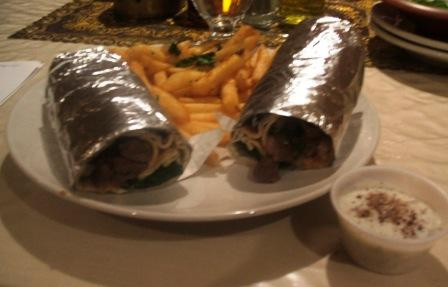

In [114]:
extract(0)

2365091
A large red and white train is traveling on tracks in a what looks to be a rural area. There are trees and hills in the background and the ground looks dry. The train has many large windows for the passengers to look out of. The train is mostly white with red on the front upper part of the train and red stripes and trim on the sides. The roof of the train is grey.


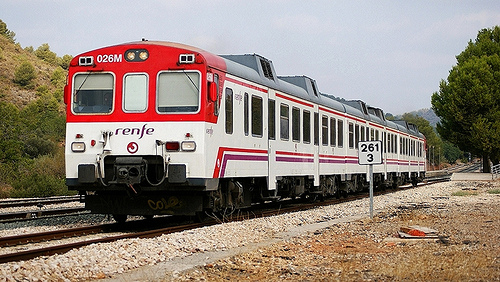

In [86]:
extract(1)


2333990
There are four small pizzas on a brown wooden plate.  There are greens in the center for garnish.  The small pizzas have broccoli, red peppers and cheese for toppings.  The wooden plate is sitting on a white table top.


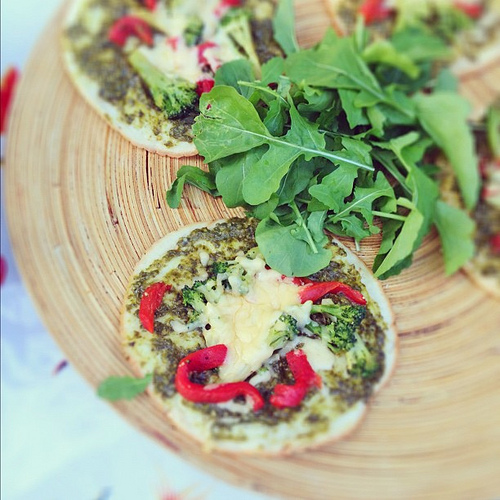

In [88]:
extract(3)


2338364
A black and white cat is sitting in a white chair. The cat is looking up at the camera. There is a black cord and a black strap on the floor in front of the chair. There is another piece of white furniture next to the chair.


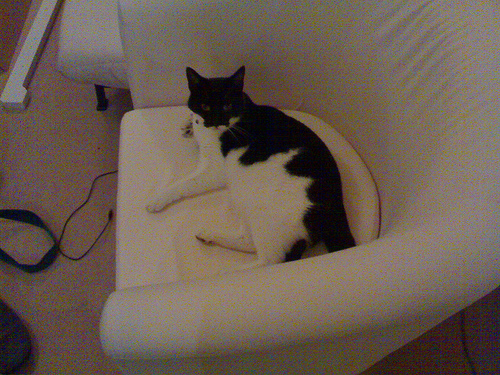

In [89]:
extract(4)


2404368
There are two people playing a video game. They have controllers in their hands. One is male and one is female. There are other people in the room with them. It looks like a party.


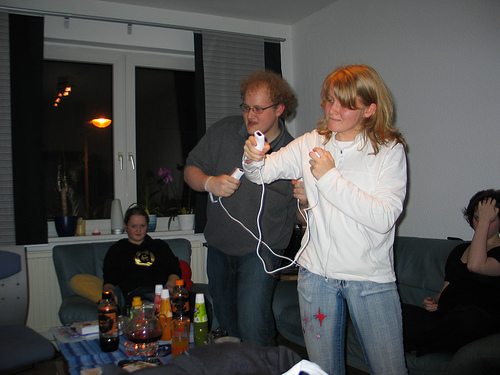

In [91]:
extract(6)


In [149]:
import keras
model=keras.applications.VGG16(weights="imagenet"
)
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [150]:
import keras
from keras.models import Model
updated_model=Model(inputs=model.input,outputs=model.layers[-4].output)
updated_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [156]:
import numpy as np
def new(i):


  url=train_data.iloc[i]['url']

  my_res=requests.get(url)

  img = Image.open(BytesIO(my_res.content))
  print(img.size)
  a = img.resize((224,224))

  arr = np.array(a)
  print(arr.shape)



  return arr

In [160]:
a=new(0)
print(a.shape)
keras.applications.vgg16.preprocess_input(a)
print(updated_model.predict(a))


(448, 287)
(224, 224, 3)
(224, 224, 3)


ValueError: Input 0 of layer "functional_4" is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(32, 224, 3)